## Experiment Tutorial: Two Qubits

In [9]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from qsopt.core.experimental_parameters import (
    ExperimentalParameters,
    PhysicalConstants,
    SystemDimensions,
    MeasurementProtocol,
    InteractionType,
    QubitInteraction,
    InitialStateConfig,
    InitialStateType,
    NoiseConfiguration
)
from qsopt.core.circuit import QuantumCircuit, create_ry_circuit
from qsopt.core.experiment.experiment import Experiment

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 1. Setup Experimental Parameters

In [10]:
# Define experimental parameters using nested configuration objects
inverse_pulse_width = 1
gm = 15 * inverse_pulse_width

interaction = QubitInteraction(
    qubit_indices=(0, 1),
    interaction_type=InteractionType.XX,
    chi=0.1
)

physical_constants = PhysicalConstants(
    n_qubits=2,
    chi=list(np.array([2.0, 2.0])*gm),
    photon_cavity_coupling=gm,
    inverse_pulse_width=inverse_pulse_width,
    qubit_interactions=[interaction]
)

system_dims = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=[2, 2]
)

measurement = MeasurementProtocol(
    measurement_times=list(np.array([-8.0, 0.0, 8.0])/inverse_pulse_width) 
)

initial_state = InitialStateConfig(state_type=InitialStateType.SINGLE_PHOTON)

noise_config = NoiseConfiguration(
    depolarizing=[0.0, 0.0],
    dephasing=[0.0, 0.0],
    relaxation=[0.0, 0.0]
)

exp_params = ExperimentalParameters(
    physical_constants=physical_constants,
    system_dims=system_dims,
    measurement=measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_params)

SYSTEM DIMENSIONS
  Number of qubits:          2
  Cavity levels:             2
  Qubit levels:         [2, 2]
  Field levels:              2
  Total dimension:          16
PHYSICAL CONSTANTS
  Chi:                  [30.0, 30.0]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    1.0000
  Qubit interactions:   1 interaction(s)
    [0] Qubits (0, 1): sx-sx, χ=0.1000
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      3
  Measurement times:    [-8.0, 0.0, 8.0]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.0, 0.0]
  Dephasing rate:       [0.0, 0.0]
  Relaxation rate:      [0.0, 0.0]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## 2. Setup Trainable Parameters

For two-qubit experiments, we need 4 rotation angles:
- θ1_q1, θ2_q1: Rotation angles for qubit 1
- θ1_q2, θ2_q2: Rotation angles for qubit 2

In [11]:
# Create Circuit with 4 rotation angles

initial_circuit = create_ry_circuit(n_qubits=2,
        theta_values=np.pi/2)
final_circuit = create_ry_circuit(n_qubits=2,
        theta_values=-np.pi/2)

import optax
optimizer = optax.sgd(learning_rate=1.)

print(initial_circuit)
print(final_circuit)

QuantumCircuit(2 qubits, 2 gates)
  0: RY(1.5708)[0]
  1: RY(1.5708)[1]
QuantumCircuit(2 qubits, 2 gates)
  0: RY(-1.5708)[0]
  1: RY(-1.5708)[1]


## 3. Create Two-Qubit Experiment

Initialize the experiment with our parameters. This will:
- Generate operators for the 4-subsystem composite space
- Build the time-dependent Hamiltonian
- Cache initial state and projectors

In [12]:
experiment = Experiment(exp_params, initial_circuit, final_circuit)

## 4. Run Basic Simulation

In [13]:
# Run simulation with zero rotations
callback = experiment.run_simulation(batch_size=1)

print(callback)


initialize_solvers               :  0.204860
get_measurements                 :  0.000067
get_circuits                     :  0.021968
start_measurement_loop           :  0.000007
start_simulation_with0           :  0.000009
load_cached_parameters0          :  0.000165
start_simulation0                :  0.000104
measurement0:solver_0            :  3.796161
measurement0:measure_0           :  0.000988
measurement1:solver_0            :  3.576428
measurement1:measure_0           :  0.000878
returning_simulation0            :  0.000113
start_simulation_no0             :  0.000005
load_cached_parameters0          :  0.000288
start_simulation0                :  0.000170
measurement0:solver_0            :  0.772930
measurement0:measure_0           :  0.000638
measurement1:solver_0            :  0.006198
measurement1:measure_0           :  0.000351
returning_simulation0            :  0.000061
compute_probs                    :  0.000350
save_callback                    :  0.000628

Tempo to

## 5. Optimize Rotation Angles

Now let's optimize the four rotation angles to maximize sensing contrast. By default, the optimization maximizes the detection probability `1 - P(00)` (any outcome except ground state).


In [16]:
# Optimize with default detection criterion (1 - P(00))
callback_opt = experiment.optimize_rotations(
    num_steps=100,
    batch_size=1,
    tolerance=1e-8,
    verbose=True,
    verbose_step=5,
    initial_values=[1.386437,    1.746450,    -1.385730,   -1.745745],
    renormalize_grad=False,
    optimizer=optax.adam(learning_rate=0.5)
)


Configuration:
    Max iterations: 100
    Batch size: 1
    Convergence tolerance: 1.00e-08
    Detection criterion: any excited
    Trainable parameters: 4 (2 initial circuit + 2 final circuit)
    Initial parameter values:
        param0. setup_RY(1.3864)[0]=1.386 rad (79.4°)
        param1. setup_RY(1.7465)[1]=1.746 rad (100.1°)
        param2. reset_RY(-1.3857)[0]=-1.386 rad (-79.4°)
        param3. reset_RY(-1.7457)[1]=-1.746 rad (-100.0°)
Step  setup_0     setup_1     reset_0     reset_1     Contrast    Grad Norm
---------------------------------------------------------------------------
0     1.386437    1.746450    -1.385730   -1.745745   0.981493    4.06e-03    
5     0.853100    1.580208    -0.846684   -1.424803   0.957707    2.21e-01    
10    0.644397    1.637447    -0.546573   -1.751573   0.958904    2.09e-01    
15    0.632566    1.511409    -0.686848   -1.597837   0.965763    1.50e-01    
20    0.777121    1.670057    -0.816842   -1.718532   0.971071    9.59e-02    
25 

### Visualize Optimization Progress

Let's plot how the contrast evolved during optimization:


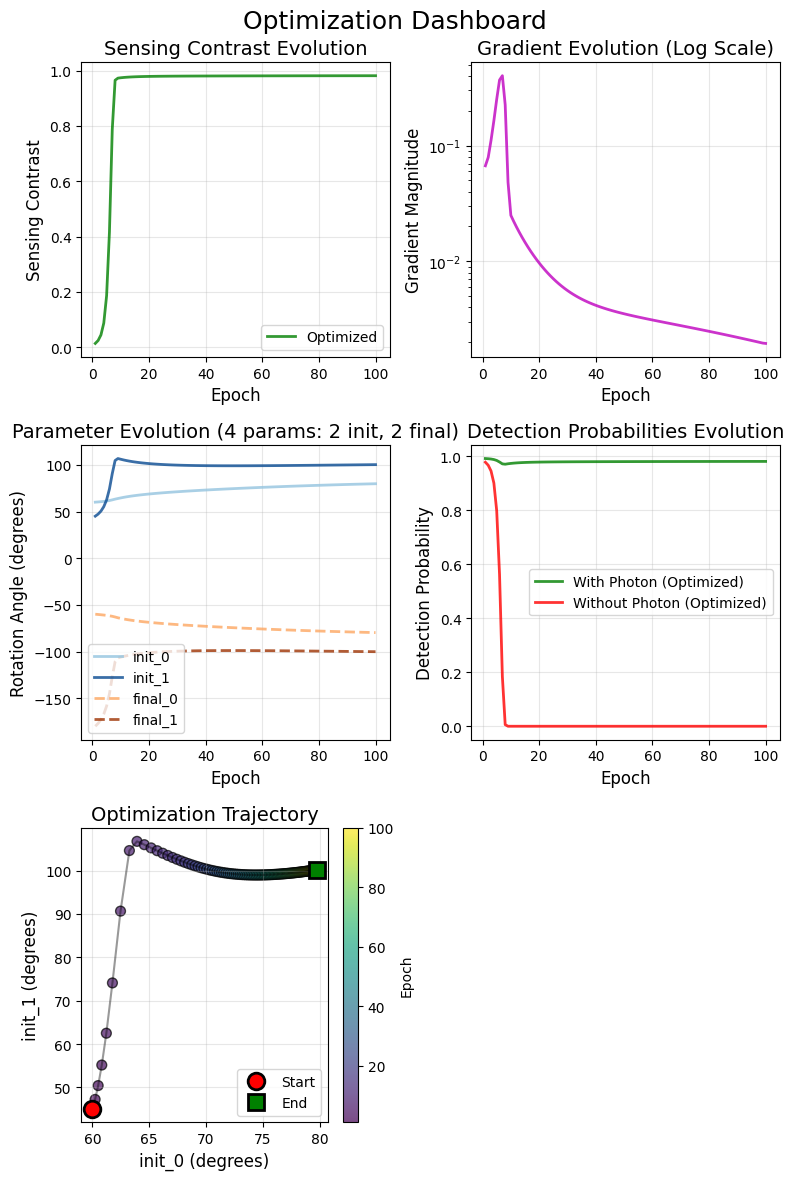

In [15]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard showing all optimization metrics
fig = plot_optimization_dashboard(
    callback_opt,
    show_contrast=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=True,
    show_probabilities=True,
    figsize=(8, 12)
)
plt.show()
